# Week-2: Data Preprocessing & Feature Engineering Pipeline
## Dataset: Titanic Passenger Survival (Kaggle)

**Goal:** Transform raw, messy Titanic data into a clean, fully numeric, ML-ready dataset.

**Problems we will solve:**
| Column | Problem | Strategy |
|--------|---------|----------|
| `Age` | 19.9% missing | Impute by median per **Title group** (not global median) |
| `Cabin` | 77.1% missing | Extract **Deck letter**; mark rest as `Unknown` |
| `Embarked` | 0.2% missing (2 rows) | Impute with mode |
| `Fare` | Max = £512, extreme right skew | Winsorise via IQR; then StandardScale |
| `Sex`, `Embarked` | Categorical strings | Binary encode / One-hot encode |
| `Name` | Free text | Extract `Title` → `Title_Group` feature |
| `Ticket`, `PassengerId` | No signal | Drop |

**Engineered features we will create:**
- `FamilySize` - total travel group including the passenger themselves
- `IsAlone` - flag for lone travellers (historically lower survival odds)
- `FarePerPerson` - corrects for shared tickets in groups

## 0. Setup & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

df_raw = pd.read_csv('titanic_raw.csv')
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
df.head()

Shape: (891, 12)

Column types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data Audit (Before State)

Before touching anything, we document exactly what problems exist. This "before snapshot" is what the before/after comparison charts later will be measured against.

In [3]:
# Missing value audit
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(1)
audit = pd.concat([missing, pct], axis=1, keys=['Missing Count', 'Missing %'])
print(audit.sort_values('Missing Count', ascending=False))

print("\nNumeric summary:")
df.describe().round(2)

             Missing Count  Missing %
Cabin                  687       77.1
Age                    177       19.9
Embarked                 2        0.2
PassengerId              0        0.0
Name                     0        0.0
Pclass                   0        0.0
Survived                 0        0.0
Sex                      0        0.0
Parch                    0        0.0
SibSp                    0        0.0
Fare                     0        0.0
Ticket                   0        0.0

Numeric summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


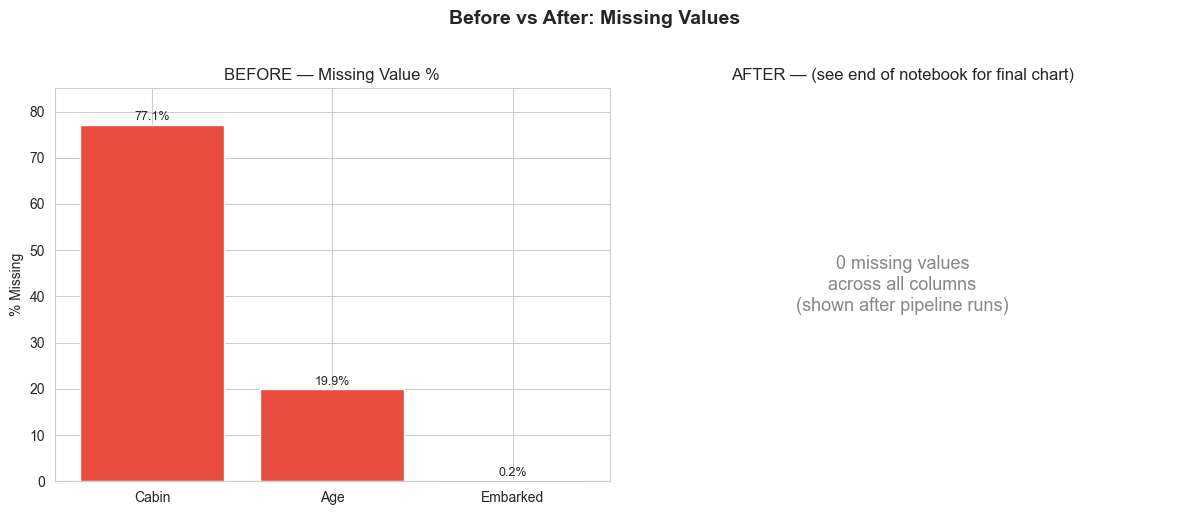

In [4]:
# Before/After missing values chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Before vs After: Missing Values', fontsize=14, fontweight='bold', y=1.02)

miss_before = df_raw.isnull().sum().sort_values(ascending=False)
miss_before = miss_before[miss_before > 0]
axes[0].bar(miss_before.index, miss_before.values / len(df_raw) * 100, color='#e74c3c', edgecolor='white')
axes[0].set_title('BEFORE — Missing Value %')
axes[0].set_ylabel('% Missing')
axes[0].set_ylim(0, 85)
for i, v in enumerate(miss_before.values):
    axes[0].text(i, v/len(df_raw)*100+1, f'{v/len(df_raw)*100:.1f}%', ha='center', fontsize=9)

axes[1].text(0.5, 0.5, '0 missing values\nacross all columns\n(shown after pipeline runs)',
             ha='center', va='center', fontsize=13, color='#888',
             transform=axes[1].transAxes)
axes[1].set_title('AFTER — (see end of notebook for final chart)')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## 2. Drop Useless Columns

`PassengerId` is only a row index with no relationship to survival. `Ticket` is a high-cardinality free-text field with inconsistent formatting, no encodable pattern that would add signal beyond what `Pclass` and `Fare` already capture. Both are dropped before any further processing.

In [5]:
df.drop(columns=['PassengerId', 'Ticket'], inplace=True)
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']


## 3. Feature Engineering from Name: Extract Title

We do this **before** imputing Age, because we will use each passenger's title (Mr, Mrs, Master, etc.) as a proxy for their age group. A simple regex extracts the title from the name string, and rare/foreign titles are consolidated into broader groups.

This step converts noisy free text into a meaningful categorical feature, and also enables smarter missing value imputation in the next step.

In [6]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()
print("Raw titles found:\n", df['Title'].value_counts())

Raw titles found:
 Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [7]:
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer',
    'Major': 'Officer', 'Capt': 'Officer',
    'the Countess': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty',
    'Lady': 'Royalty', 'Sir': 'Royalty', 'Jonkheer': 'Royalty',
    'Mlle': 'Miss',   # French for Miss
    'Ms':   'Miss',
    'Mme':  'Mrs',    # French for Mrs
}
df['Title_Group'] = df['Title'].map(title_map).fillna('Other')
df.drop(columns=['Name', 'Title'], inplace=True)

print("Title_Group distribution:\n", df['Title_Group'].value_counts())

Title_Group distribution:
 Title_Group
Mr         517
Miss       185
Mrs        126
Master      40
Officer     18
Royalty      5
Name: count, dtype: int64


## 4. Handle Cabin: Extract Deck

`Cabin` is 77% missing, too much to impute meaningfully. But the cabin number starts with a **deck letter** (A–G, T) that encodes the physical deck of the ship, which correlates with class and proximity to lifeboats. We extract that letter where available and label the rest `'Unknown'`. The original `Cabin` column is then dropped.

In [8]:
df['Deck'] = df['Cabin'].str.extract(r'([A-Z])', expand=False).fillna('Unknown')
df.drop(columns=['Cabin'], inplace=True)

print("Deck distribution:\n", df['Deck'].value_counts())

Deck distribution:
 Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


## 5. Impute Age - Per Title Group (Not Global Median)

The most common mistake when imputing `Age` is using the global median (≈28). This assigns 28 to both 'Master' passengers (young boys) and 'Mr' passengers (adult men), which is clearly wrong.

**Better approach:** compute the median age *per Title Group* and fill missing values with the group-specific median. This preserves demographic reality in the imputed values.

| Title Group | Median Age |
|-------------|-----------|
| Master | 3.5 |
| Miss | 21 |
| Mr | 30 |
| Mrs | 35 |
| Officer | 50 |
| Royalty | 40 |

In [9]:
age_medians = df.groupby('Title_Group')['Age'].median()
print("Median ages per group:\n", age_medians)

null_before = df['Age'].isnull().sum()
df['Age'] = df.apply(
    lambda row: age_medians[row['Title_Group']] if pd.isnull(row['Age']) else row['Age'],
    axis=1
)
print(f"\nImputed {null_before} missing Age values → now {df['Age'].isnull().sum()} missing")

Median ages per group:
 Title_Group
Master      3.5
Miss       21.0
Mr         30.0
Mrs        35.0
Officer    50.0
Royalty    40.0
Name: Age, dtype: float64

Imputed 177 missing Age values → now 0 missing


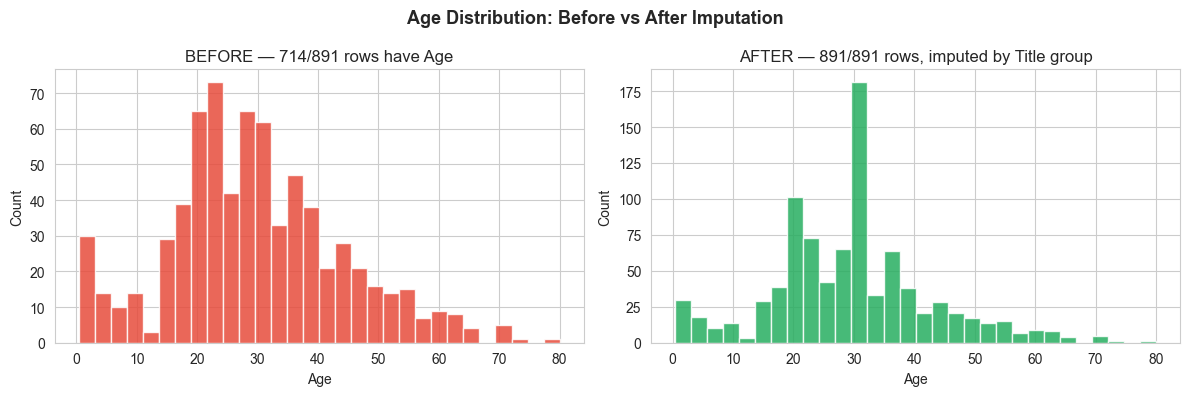

In [10]:
# Compare Age distributions before and after imputation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Age Distribution: Before vs After Imputation', fontsize=13, fontweight='bold')

axes[0].hist(df_raw['Age'].dropna(), bins=30, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title(f'BEFORE — 714/891 rows have Age')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

axes[1].hist(df['Age'], bins=30, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].set_title('AFTER — 891/891 rows, imputed by Title group')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

## 6. Impute Embarked (2 Missing Rows)

Only 2 rows are missing `Embarked`. The appropriate fix is simple: fill with the mode (most frequent value). Overthinking a 0.2% missingness rate is not worth it.

In [11]:
print("Embarked value counts:\n", df['Embarked'].value_counts())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("\nMissing Embarked after imputation:", df['Embarked'].isnull().sum())

Embarked value counts:
 Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Missing Embarked after imputation: 0


## 7. Outlier Handling - Winsorise Fare (IQR Method)

`Fare` ranges from £0 to £512 with a mean of £32 and heavy right skew, a classic long-tail distribution. Three passengers paid £512+, pulling the distribution far from the bulk of the data.

**Strategy: Winsorisation (capping), not removal.** We cap values at the IQR fence rather than dropping rows, so no data is lost. Removing outlier rows would bias the dataset (wealthy passengers are an important demographic in survival analysis).

- Lower fence = Q1 - 1.5 × IQR
- Upper fence = Q3 + 1.5 × IQR
- Values outside these are clamped to the fence value

In [12]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
print(f"Fences: [{lower_fence:.2f}, {upper_fence:.2f}]")
print(f"Outlier rows affected: {((df['Fare'] < lower_fence) | (df['Fare'] > upper_fence)).sum()}")

df['Fare'] = df['Fare'].clip(lower=lower_fence, upper=upper_fence)
print(f"\nFare max after winsorising: {df['Fare'].max():.2f}")

Q1=7.91  Q3=31.00  IQR=23.09
Fences: [-26.72, 65.63]
Outlier rows affected: 116

Fare max after winsorising: 65.63


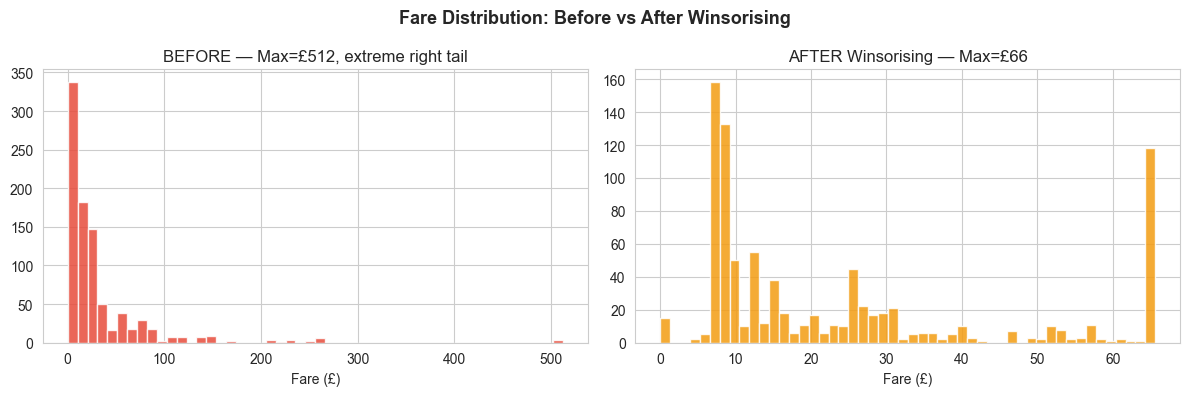

In [13]:
# Fare before vs after winsorising
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fare Distribution: Before vs After Winsorising', fontsize=13, fontweight='bold')

axes[0].hist(df_raw['Fare'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title(f'BEFORE — Max=£{df_raw["Fare"].max():.0f}, extreme right tail')
axes[0].set_xlabel('Fare (£)')

axes[1].hist(df['Fare'], bins=50, color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_title(f'AFTER Winsorising — Max=£{df["Fare"].max():.0f}')
axes[1].set_xlabel('Fare (£)')

plt.tight_layout(); plt.show()

## 8. Feature Engineering

### Feature 1: FamilySize
`SibSp` (siblings + spouses) and `Parch` (parents + children) both carry some signal, but their sum, the total family unit size, is more interpretable and arguably more directly linked to evacuation dynamics. Adding 1 accounts for the passenger themselves.

### Feature 2: IsAlone
A binary flag for passengers travelling alone. Historical analysis of the Titanic suggests lone travellers (especially adult men) fared worse, as they lacked a support group during evacuation. This collapses `FamilySize==1` into a simple interpretable feature.

### Feature 3: FarePerPerson
Some tickets were purchased for entire family groups, meaning the recorded `Fare` is the total cost, not per-person. Dividing by `FamilySize` gives a more accurate per-head cost estimate.

In [14]:
# Engineer all 3 new features
df['FamilySize']    = df['SibSp'] + df['Parch'] + 1
df['IsAlone']       = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = (df['Fare'] / df['FamilySize']).round(4)

print("New feature sample:")
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']].head(8))

New feature sample:
   SibSp  Parch  FamilySize  IsAlone     Fare  FarePerPerson
0      1      0           2        0   7.2500         3.6250
1      1      0           2        0  65.6344        32.8172
2      0      0           1        1   7.9250         7.9250
3      1      0           2        0  53.1000        26.5500
4      0      0           1        1   8.0500         8.0500
5      0      0           1        1   8.4583         8.4583
6      0      0           1        1  51.8625        51.8625
7      3      1           5        0  21.0750         4.2150


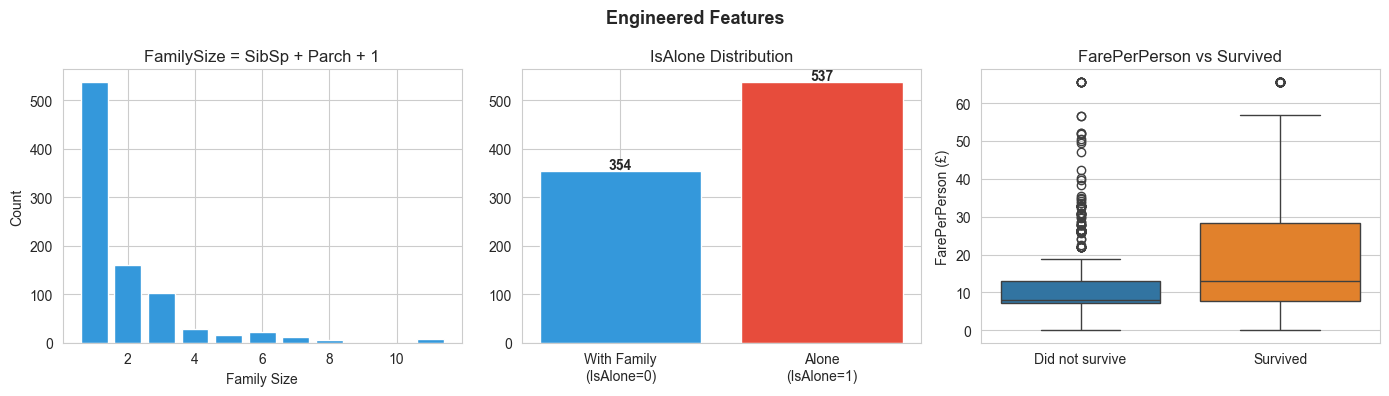

In [15]:
# Visualise the engineered features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Engineered Features', fontsize=13, fontweight='bold')

# FamilySize distribution
fs_counts = df['FamilySize'].value_counts().sort_index()
axes[0].bar(fs_counts.index, fs_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('FamilySize = SibSp + Parch + 1')
axes[0].set_xlabel('Family Size'); axes[0].set_ylabel('Count')

# IsAlone breakdown
axes[1].bar(['With Family\n(IsAlone=0)', 'Alone\n(IsAlone=1)'],
            [df['IsAlone'].value_counts()[0], df['IsAlone'].value_counts()[1]],
            color=['#3498db','#e74c3c'], edgecolor='white')
axes[1].set_title('IsAlone Distribution')
for i, v in enumerate([df['IsAlone'].value_counts()[0], df['IsAlone'].value_counts()[1]]):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')

# FarePerPerson vs survival
sns.boxplot(x=df_raw['Survived'].values, y=df['FarePerPerson'].values,
            ax=axes[2], hue=df_raw['Survived'].values, legend=False)
axes[2].set_title('FarePerPerson vs Survived')
axes[2].set_xticklabels(['Did not survive', 'Survived'])
axes[2].set_ylabel('FarePerPerson (£)')

plt.tight_layout(); plt.show()

## 9. Encode Categorical Variables

Three encoding decisions:

- **`Sex`** -> Binary (0=male, 1=female). Only 2 categories; one-hot would be redundant.
- **`Embarked`** -> One-hot encode with `drop_first=True` to avoid the dummy variable trap (multicollinearity). 3 categories → 2 columns.
- **`Title_Group`** -> One-hot encode with `drop_first=True`. 6 categories → 5 columns.
- **`Deck`** -> One-hot encode with `drop_first=True`. Categorical position information.

After this step, **no object-type columns remain** - the entire dataset is numeric.

In [16]:
print("Object columns before encoding:", df.select_dtypes(include='object').columns.tolist())

df['Sex'] = (df['Sex'] == 'female').astype(int)

df = pd.get_dummies(df, columns=['Embarked'],    drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['Title_Group'], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['Deck'],        drop_first=True, dtype=int)

print("Object columns after encoding: ", df.select_dtypes(include='object').columns.tolist())
print("\nNew columns added:")
print(df.columns.tolist())

Object columns before encoding: ['Sex', 'Embarked', 'Title_Group', 'Deck']
Object columns after encoding:  []

New columns added:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Embarked_Q', 'Embarked_S', 'Title_Group_Miss', 'Title_Group_Mr', 'Title_Group_Mrs', 'Title_Group_Officer', 'Title_Group_Royalty', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_Unknown']


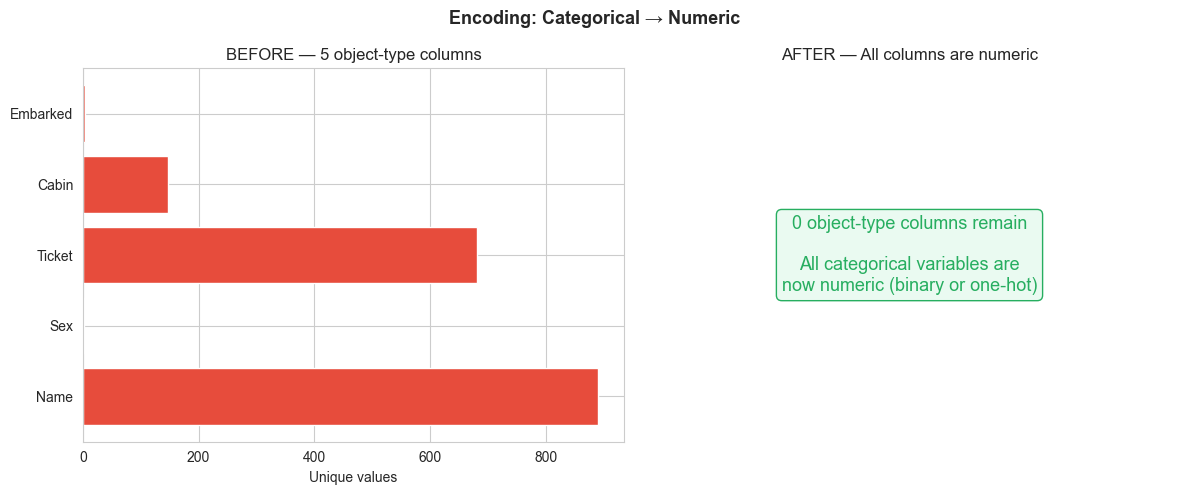

In [17]:
# Visualise encoding result
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Encoding: Categorical → Numeric', fontsize=13, fontweight='bold')

cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
axes[0].barh(cat_cols, [df_raw[c].nunique() for c in cat_cols], color='#e74c3c', edgecolor='white')
axes[0].set_title(f'BEFORE — {len(cat_cols)} object-type columns')
axes[0].set_xlabel('Unique values')

axes[1].text(0.5, 0.5, f'0 object-type columns remain\n\nAll categorical variables are\nnow numeric (binary or one-hot)',
             ha='center', va='center', fontsize=13, color='#27ae60', transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#eafaf1', edgecolor='#27ae60'))
axes[1].set_title('AFTER — All columns are numeric')
axes[1].set_axis_off()
plt.tight_layout(); plt.show()

## 10. Scale Numeric Features (StandardScaler)

StandardScaler transforms each numeric feature so it has **mean = 0** and **std = 1**. This is important for:
- Distance-based models (KNN, SVM) where large-scale features would dominate
- Linear models where coefficient magnitudes would otherwise be incomparable
- Gradient-based methods that converge faster with normalised inputs

We scale: `Age`, `Fare`, `FamilySize`, `FarePerPerson`, `SibSp`, `Parch`. We leave `Pclass`, `Sex`, `Survived`, and all binary columns alone - scaling binary (0/1) columns is harmless but unnecessary.

In [18]:
scale_cols = ['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'SibSp', 'Parch']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Post-scaling statistics:")
print(df[scale_cols].describe().round(3))

Post-scaling statistics:
           Age     Fare  FamilySize  FarePerPerson    SibSp    Parch
count  891.000  891.000     891.000        891.000  891.000  891.000
mean     0.000    0.000      -0.000          0.000    0.000    0.000
std      1.001    1.001       1.001          1.001    1.001    1.001
min     -2.185   -1.175      -0.561         -1.060   -0.475   -0.474
25%     -0.633   -0.788      -0.561         -0.552   -0.475   -0.474
50%      0.046   -0.469      -0.561         -0.479   -0.475   -0.474
75%      0.423    0.340       0.059          0.092    0.433   -0.474
max      3.815    2.032       5.640          3.535    6.784    6.974


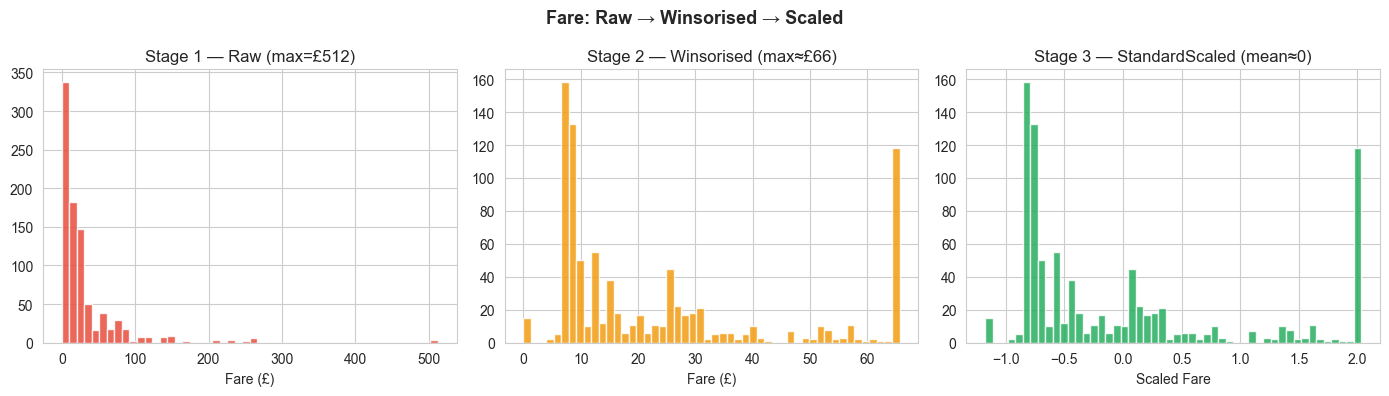

In [19]:
# Fare: raw → winsorised → scaled  (3-stage comparison)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Fare: Raw → Winsorised → Scaled', fontsize=13, fontweight='bold')

axes[0].hist(df_raw['Fare'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Stage 1 — Raw (max=£{df_raw["Fare"].max():.0f})')
axes[0].set_xlabel('Fare (£)')

fare_winsor = df_raw['Fare'].clip(lower=lower_fence, upper=upper_fence)
axes[1].hist(fare_winsor, bins=50, color='#f39c12', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Stage 2 — Winsorised (max≈£{upper_fence:.0f})')
axes[1].set_xlabel('Fare (£)')

axes[2].hist(df['Fare'], bins=50, color='#27ae60', edgecolor='white', alpha=0.85)
axes[2].set_title('Stage 3 — StandardScaled (mean≈0)')
axes[2].set_xlabel('Scaled Fare')

plt.tight_layout(); plt.show()

## 11. Before vs After Summary

In [20]:
print("BEFORE vs AFTER COMPARISON")
print(f"  Rows:              {df_raw.shape[0]}  →  {df.shape[0]}  (no rows dropped)")
print(f"  Columns:           {df_raw.shape[1]}  →  {df.shape[1]}")
print(f"  Missing values:    {df_raw.isnull().sum().sum()}  →  {df.isnull().sum().sum()}")
print(f"  Object columns:    {(df_raw.dtypes == object).sum()}  →  {(df.dtypes == object).sum()}")
print(f"  Numeric columns:   {(df_raw.dtypes != object).sum()}  →  {(df.dtypes != object).sum()}")
print("\nFinal column list:")
for c in df.columns:
    print(f"  {c}")

BEFORE vs AFTER COMPARISON
  Rows:              891  →  891  (no rows dropped)
  Columns:           12  →  25
  Missing values:    866  →  0
  Object columns:    5  →  0
  Numeric columns:   7  →  25

Final column list:
  Survived
  Pclass
  Sex
  Age
  SibSp
  Parch
  Fare
  FamilySize
  IsAlone
  FarePerPerson
  Embarked_Q
  Embarked_S
  Title_Group_Miss
  Title_Group_Mr
  Title_Group_Mrs
  Title_Group_Officer
  Title_Group_Royalty
  Deck_B
  Deck_C
  Deck_D
  Deck_E
  Deck_F
  Deck_G
  Deck_T
  Deck_Unknown


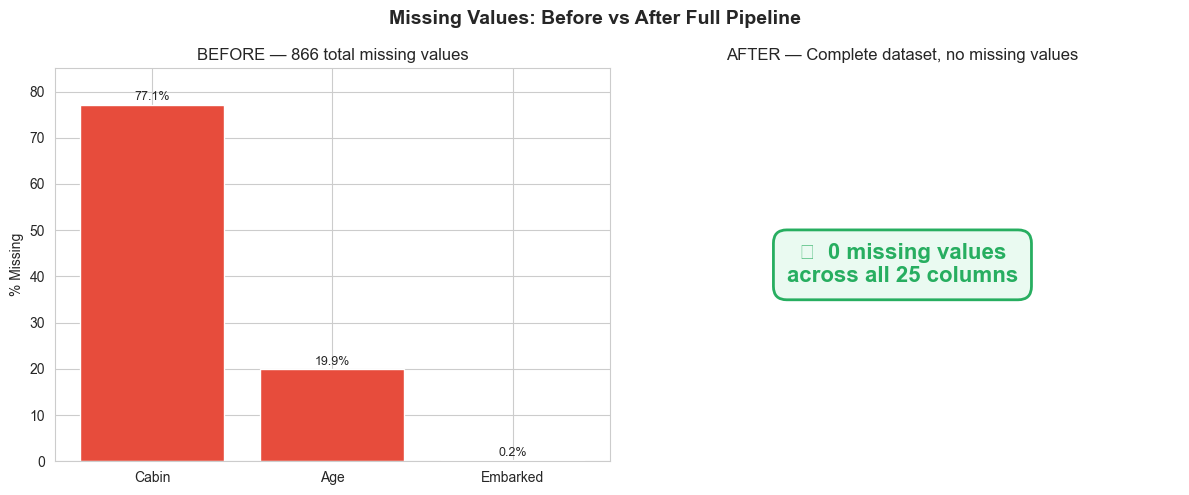

In [21]:
# Final missing value confirmation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Missing Values: Before vs After Full Pipeline', fontsize=14, fontweight='bold')

miss_before = df_raw.isnull().sum().sort_values(ascending=False)
miss_before = miss_before[miss_before > 0]
axes[0].bar(miss_before.index, miss_before.values/len(df_raw)*100, color='#e74c3c', edgecolor='white')
axes[0].set_title(f'BEFORE — {df_raw.isnull().sum().sum()} total missing values')
axes[0].set_ylabel('% Missing'); axes[0].set_ylim(0, 85)
for i, v in enumerate(miss_before.values):
    axes[0].text(i, v/len(df_raw)*100+1, f'{v/len(df_raw)*100:.1f}%', ha='center', fontsize=9)

axes[1].text(0.5, 0.5, '✓  0 missing values\nacross all 25 columns',
             ha='center', va='center', fontsize=16, color='#27ae60',
             transform=axes[1].transAxes, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#eafaf1', edgecolor='#27ae60', linewidth=2))
axes[1].set_title('AFTER — Complete dataset, no missing values')
axes[1].set_axis_off()
plt.tight_layout(); plt.show()

In [22]:
# Save the cleaned dataset
df.to_csv('titanic_cleaned.csv', index=False)
print(f"Saved titanic_cleaned.csv  ({df.shape[0]} rows × {df.shape[1]} columns)")
df.head()

Saved titanic_cleaned.csv  (891 rows × 25 columns)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,FarePerPerson,...,Title_Group_Officer,Title_Group_Royalty,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
0,0,3,0,-0.557481,0.432793,-0.473674,-0.820552,0.059160,0,-0.806026,...,0,0,0,0,0,0,0,0,0,1
1,1,1,1,0.648840,0.432793,-0.473674,2.031623,0.059160,0,1.237601,...,0,0,0,1,0,0,0,0,0,0
2,1,3,1,-0.255901,-0.474545,-0.473674,-0.787578,-0.560975,1,-0.505001,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1,0.422655,0.432793,-0.473674,1.419297,0.059160,0,0.798860,...,0,0,0,1,0,0,0,0,0,0
4,0,3,0,0.422655,-0.474545,-0.473674,-0.781471,-0.560975,1,-0.496250,...,0,0,0,0,0,0,0,0,0,1
